In [226]:
#import packages
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import os
import yaml
import itertools
import shutil
from datetime import datetime
from pathlib import Path
from openpyxl.styles import PatternFill
from openpyxl import load_workbook
from collections import defaultdict
import sys
from openpyxl.styles import Border, Side
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter
from numpy._core.numeric import indices
from tqdm import tqdm
from functools import lru_cache
from collections import deque
import networkx as nx
from collections import Counter


#set working dir
os.chdir("/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project")

In [ ]:
# load cores
project = 'Bipolar'
output_dir = 'table_out/'

# get all link combos
with open(f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/{project}/parameters.yml') as f:
    data = yaml.safe_load(f)
list_sites = data["list_sites"]
pairs = [f"{a}-{b}" for a, b in itertools.combinations(list_sites, 2)]

#define error margins
error_margin = 0.15

In [228]:
big_table = pd.DataFrame()
all_links_count = {}
all_links_foragesort = {}
all_links_total = {}

for core in list_sites: # loop through each core
    for comparison_core in list_sites: # loop through each core other than the initial load
        pair = f"{core}-{comparison_core}"
        if core != comparison_core and pair in pairs: # make sure not the same core and we skip non-existent linkages
            pair_dir = Path(f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/{project}/{pair}')

            # Check: directory exists AND contains at least one .txt file
            txt_files = list(pair_dir.glob("*.txt"))
            if not pair_dir.is_dir() or not txt_files:
                continue

            dfs=[] #load all text files into one
            for txt in txt_files:
                df = pd.read_csv(txt, sep="\t", comment="#")
                dfs.append(df)
    
            num_files = len(dfs)
            load_data = pd.concat(dfs, ignore_index=True)
            original_rows = len(load_data)

            drop_rows = []
            drop_rows_merge = set()
            new_merged_rows = []
            for idx, row in load_data.iterrows():

                mask1 = abs(row['depth1'] - load_data['depth1']) <= error_margin
                mask1[idx] = False
                mask2 = abs(row['depth2'] - load_data['depth2']) <= error_margin 
                mask2[idx] = False

                close_points = load_data[mask1 & mask2]
                num_close = len(close_points)
                close_idxs = load_data.index[mask1 & mask2]

                if num_close > 0:
                    refs = [load_data.at[idx, 'reference']] + [load_data.at[i, 'reference'] for i in close_idxs] #adjoin references
                    merged_ref = "; ".join(str(r) for r in refs if pd.notna(r))

                    depth1_vals = [load_data.at[idx, 'depth1']] + [load_data.at[i, 'depth1'] for i in close_idxs]
                    merged_depth1 = np.round(np.mean(depth1_vals), 4)

                    depth2_vals = [load_data.at[idx, 'depth2']] + [load_data.at[i, 'depth2'] for i in close_idxs]
                    merged_depth2 = np.round(np.mean(depth2_vals), 4)

                    new_merged_rows.append({'reference': merged_ref, 'depth1': merged_depth1, 'depth2': merged_depth2}) #create new merged row

                    drop_rows_merge.add(idx)
                    for i in close_idxs:
                        drop_rows.append(i)
                        if drop_rows.count(i) >= num_files:
                            print(f'WARNING: Row {load_data.at[i, 'depth1']} | {load_data.at[i, 'depth2']} for {pair}. Reference {load_data.at[i, 'reference']}.')
                            print(f'Called by row {load_data.at[idx, 'depth1']} | {load_data.at[idx, 'depth2']} from reference {load_data.at[idx, 'reference']}.')

            # drop duplicate rows
            drop_rows = set(drop_rows).union(drop_rows_merge)
            load_data = load_data.drop(index=drop_rows).reset_index(drop=True)
            # add merged rows
            merged_df = pd.DataFrame(new_merged_rows)
            load_data = pd.concat([load_data, merged_df], ignore_index=True)
            load_data.drop_duplicates(subset=['depth1', 'depth2'], inplace=True)
            load_data = load_data.reset_index(drop=True)

            load_data = load_data.sort_values(by=['depth1']).reset_index(drop=True)
        
            #set up pair code stuff
            load_data[f"{pair}_code"] = [f"{pair}_{idx}" for idx in load_data.index]

            #save all the links for this pair
            all_links_total[f'{pair}'] = load_data[['depth1', 'depth2']].copy(deep=True)
            all_links_total[f'{pair}'] = all_links_total[f'{pair}'].rename(columns={
                'depth1': pair.split("-")[0],
                'depth2': pair.split("-")[1]})

            # rename to create unique columns for this pair
            load_data = load_data.rename(columns={
                'depth1': f"{pair}_{core}",
                'depth2': f"{pair}_{comparison_core}",
                'reference': f"{pair}_reference",
            })

            print(f"Processed pair {pair}, total points after merging: {len(load_data)}, ({original_rows} original total rows)")
            # append rows (block)
            big_table = pd.concat([big_table, load_data],
                                  axis=0,
                                  ignore_index=True)

#if core doesn't exist in all_links_count, add it with 0 val
for core in list_sites:
    if core not in all_links_count:
        all_links_count[core] = 0

big_table.to_csv(f'/Users/quinnmackay/Desktop/output2.csv', index=False)

Processed pair GISP2-NG1, total points after merging: 290, (290 original total rows)
Processed pair GISP2-NG2, total points after merging: 614, (725 original total rows)
Processed pair GISP2-NEEM, total points after merging: 194, (194 original total rows)
Called by row 1663.938 | 1609.565 from reference Seierstad2014_Rasmussen2014.
Processed pair GISP2-GRIP, total points after merging: 823, (918 original total rows)
Called by row 486.188 | 485.82 from reference GICC21.
Processed pair NG1-NG2, total points after merging: 309, (311 original total rows)
Called by row 226.357 | 255.635 from reference GICC21.
Called by row 355.452 | 396.399 from reference GICC21.
Called by row 226.239 | 255.536 from reference NEEM-GICC05.
Called by row 226.239 | 255.536 from reference NEEM-GICC05.
Processed pair NG1-NEEM, total points after merging: 570, (673 original total rows)
Processed pair NG1-GRIP, total points after merging: 519, (587 original total rows)
Processed pair NG2-NEEM, total points after m

In [229]:
def get_core_pair(node): #takes a node (which is a tuple of (index, root_core)) and outputs the other pair in the same row of big_table
    idx, root_core = node

    root_core_row = big_table.loc[idx].dropna() #locates the row
    if root_core_row.index[0].split("_")[0].split("-")[0] == root_core: #if the first part of the pair is the root core, return the second part
        root_core_pair = root_core_row.index[0].split("_")[0].split("-")[1]
    elif root_core_row.index[0].split("_")[0].split("-")[1] == root_core: #if the second part of the pair is the root core, return the first part
            root_core_pair = root_core_row.index[0].split("_")[0].split("-")[0]
    else: #just in case
        sys.exit(f"ERROR: Could not determine root core pair for root core {root_core}.")

    return root_core_pair

def readable_paths(paths): #takes a list of paths (which are lists of tuples of (pair, core)) and outputs a list of paths in the format "core1-core2 and the index"
    readable_all = []
    for root_core, path in paths: #paths is a list of (root_core, (list of tuples of (pair, core)))
        readable = []
        root = root_core[1]

        for i, p in enumerate(path): 
            if i == 0:
                readable.append(f"{root}-{p[1]} ({p[0]})") #for the first pair, use the root core and the other core in the pair
            else:
                readable.append(f"{path[i-1][1]}-{p[1]} ({p[0]})") #for subsequent pairs, use the previous core and the other core in the pair
        readable_all.append(readable)

    return readable_all



In [230]:
def find_matches(index, core_name): # Find the matches for a given index, core_name. Outputs a list of matching indices and their associated core names.
    match_indices = []  # empty array
    match_cores = [] # empty array

    row_vals = big_table.loc[index] #get the row values for the given index
    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist() #get the non-zero columns for the given index

    #pick the active column for this core from the non-zero columns, since only 2 active columns per row
    core_columns = [col for col in non_zero_columns if col.endswith(core_name)] #find the column that ends with the core name, which is the core we are looking for matches for
    if not core_columns: #just in case
        print(f"No active columns found for core {core_name} in row {index}.")
        sys.exit()

    column_name = core_columns[0]
    core_value = big_table.at[index, column_name]  # get value of core in current row

    #below filters 
    for column in big_table.columns:  # for every column in big_table

        if column.endswith(core_name): #make sure column is same core
            for idx, value in big_table[column].items(): #for every value in the column
                if pd.notna(value) and abs(value - core_value) <= error_margin: #if value is not NA and within error margin, add index to match_indices
                    match_indices.append(idx)

                    col_check1 = column.split("-")[0]
                    col_check2 = column.split("-")[1].split("_")[0]
                    if col_check1 != core_name: #if the first part of the pair is not the core name, then it must be the matching core
                        matching_core = col_check1
                    elif col_check2 != core_name: #if the second part of the pair is not the core name, then it must be the matching core
                        matching_core = col_check2
                    else:
                        print(f"ERROR: Could not determine matching core for column {column} in row {index}.")
                        sys.exit()
                    match_cores.append(matching_core)
                    
    return match_indices, match_cores

@lru_cache(maxsize=None)
def find_matches_cached(index, core_name): #cache the find_matches function to speed up calls
    return find_matches(index, core_name)

def walk_back(current_floor_number, network): #walk back to root to get path. 
    if current_floor_number == 0: #no path on first floor, since it is the root.
        return [], []
    path = [] #blank indices and path
    
    current_slot = len([n for n in network if n[0] == current_floor_number]) #get current slot in network for this floor, which is just the total number of nodes.

    for floor in range(current_floor_number-1, -1, -1): #walk back through floors
        addition_mod = 0 #the addition modifier
        floor_nodes = [n for n in network if n[0] == floor] # get the nodes for this floor
        for i, fnode in enumerate(floor_nodes): #for each node in the floor
            addition_mod += fnode[3] #add the number of matches for this node to the addition modifier
            if addition_mod >= current_slot+1: # if the addition modifier is greater than or equal to the current slot, we have found the parent node
                path.append(fnode) #add the parent node to the path
                current_slot = i #update the current slot to the index of the parent node 
                break #break to move to next floor

    path = [(p[1], p[2]) for p in path] #convert path to list of tuples of (index, core) for readability
    indices = [idx for idx, _ in path] #return the indices from the existing path
    return indices, path

def bfs(root_index, root_core, *, max_floor=20): #breadth-first-search
    root = (root_index, root_core) #create root node as a tuple of (index, core)
    root_pair = (root_index, get_core_pair(root)) #create root pair as a tuple of (index, core pair) using the get_core_pair function to find the core pair for the root core

    queue = deque([root_pair]) #this uses deque, which is a double-ended queue that allows for efficient appending and popping from both ends, to create the initial queue with the root pair as the only element.
    next_floor = deque() #this will be used to store the nodes for the next floor as we find matches for the current floor
    network = [] #creates empty network variable
    current_floor_number = 0 #start at floor zero, which is the root node
    export_pathways = [] #store the pathways found for export

    while queue: #while there are still nodes to explore in the queue

        if current_floor_number > max_floor: #if we have exceeded the maximum floor,
            break

        floor_width = len(queue) #the width of the current floor is the number of nodes in the queue at the start of the floor
        for _ in range(floor_width): #for each node in the current floor
            node = queue.popleft() #current node removes from left of queue
            idx, core = node #unpack the node into index and core

            extracted_numbers, existing_path = walk_back(current_floor_number, network) #walk back and get all the indices and the full path
            
            if idx in extracted_numbers: #if the index of the current node is already in the existing path, we have looped back around to a previously visited node, so we can stop exploring this path and add it to the export pathways
                match_indices, match_cores = [], [] #clear match indices and cores since we are not exploring this path anymore
                existing_path.insert(0, node) #insert the node at beginning to preserve order
                existing_path.reverse() #reverse to get correct order from root to leaf
                export_pathways.append((root, existing_path)) #add the root and the existing path to the export pathways
            elif core != root_core or current_floor_number == 0: #if the core is not the root core, or if we are on the first floor (since the first floor is the root node and we want to find matches for it), find matches and add them to the next floor
                match_indices, match_cores = find_matches_cached(idx, core) #find matches for the current node
                next_floor.extend(zip(match_indices, match_cores)) #add matches to next floor
            elif core == root_core: #if the core is the same as the root core, we have found a loop back to the root, so we can add this path to the export pathways
                match_indices, match_cores = [], [] #clear match indices and cores since we are not exploring this path anymore
                existing_path.insert(0, node) #insert at beginning to preserve order
                existing_path.reverse() #reverse to get correct order from root to leaf
                export_pathways.append((root, existing_path)) #add the root and the existing path to the export pathways

            network.append((current_floor_number, idx, core, len(match_indices)))  #the full network, saved but not used.
        
        current_floor_number += 1 #increment floor number after exploring all nodes in the current floor
        queue.extend(next_floor) #add the nodes for the next floor to the queue to explore in the next iteration of the while loop
        next_floor.clear() #clear the next floor for the next iteration

    
    return export_pathways, network

In [231]:
# for each row, start DFS from each core on that row 
every_path = []
for index, row in tqdm(big_table.iterrows(), total=len(big_table), desc="DFS", unit="row", position=0): #for each row in big_table
    row = row.dropna() #drop NA values to avoid confusion
    core1 = row.index[0].split("-")[0] #names of the cores
    core2 = row.index[0].split("-")[1].split("_")[0]

    for core in (core1, core2): #for each core

        paths, network = bfs(index, core, max_floor=6) #get paths and network from BFS
        for p in paths:
            every_path.append(p)

DFS: 100%|██████████| 5437/5437 [00:30<00:00, 175.51row/s] 


In [232]:
def get_depth(core, index): #function to grab the depth based on core and index
    row_vals = big_table.loc[index]
    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist()

    core_columns = [col for col in non_zero_columns if col.endswith(core)]
    if not core_columns:
        print(f"No active columns found for core {core} in row {index}.")
        sys.exit()

    column_name = core_columns[0]
    return big_table.at[index, column_name]

def get_code(index): #function to grab the code based on index
    row_vals = big_table.loc[index]

    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist()

    code_columns = [c for c in non_zero_columns if c.endswith("code")]
    if not code_columns:
        print(f"No code column found for row {index}.")
        sys.exit()

    return big_table.at[index, code_columns[0]]

def get_reference(index): #function to grab the reference based on index
    row_vals = big_table.loc[index]

    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist()

    reference_columns = [c for c in non_zero_columns if c.endswith("reference")]
    if not reference_columns:
        print(f"No reference column found for row {index}.")
        sys.exit()

    return big_table.at[index, reference_columns[0]]

In [233]:
error_networks = 0 #number of error networks
circular_networks = 0 #total number of circular networks


naughty_list = set() #use sets for unique values
nice_list = set()

for i, path in tqdm(enumerate(every_path), total=len(every_path), desc="Getting depths", unit="path"): #for each path in every_path, get the root core and end node core, and if they are the same, check if the depth difference is within the error margin.
    
    root_core = every_path[i][0][1] #gets the root core
    root_index = every_path[i][0][0] #gets the root index

    end_node_core = every_path[i][1][-1][1] #gets the end node core, which is the core of the last node in the path
    end_node_index = every_path[i][1][-1][0] #get the end node index, which is the index of the last node in the path

    all_indices = [node[0] for node in every_path[i][1]] #gets all the indices in the path, which will be used to add to the naughty or nice list depending on whether this path is an error network or not

    if root_core != end_node_core: #if not circular, skip
        continue

    if len(all_indices) < 3: #if the path is too short to be successful, skip
        continue

    else:

        circular_networks += 1 #add to toal cicular
        root_depth = get_depth(root_core, root_index) #get the root depth
        end_node_depth = get_depth(end_node_core, end_node_index) #get the end node depth
        if abs(root_depth - end_node_depth) >= error_margin: #if depths differ more than by error margin, error network
            error_networks += 1

            for idx in all_indices: #put all the indices in the naughty list, unless in nice list
                if idx in nice_list:
                    continue
                else:
                    naughty_list.add(idx)

        elif abs(root_depth - end_node_depth) <= error_margin: #else, everything into nice list
            
            for idx in all_indices:
                nice_list.add(idx)
                if idx in naughty_list:
                    naughty_list.remove(idx)


Getting depths: 100%|██████████| 191702/191702 [00:07<00:00, 24715.73path/s]


In [234]:
#Code to check for first order errors (aka two cores with one side within 0.15 and the other not)
print(f"naughty: {len(naughty_list)}")
print(f"nice: {len(nice_list)}")

#creating a new set to avoid modifying original set
appended_naughty = set(naughty_list)

#create lists
row_index_list = []
group_key_list = []
depth1_list = []
depth2_list = []

#for every row in big_table
for idx, row in big_table.iterrows():
    row = row.dropna()
    row_index_list.append(idx) #
    group_key_list.append(row.index[0])   # (example: EDC-WDC_0), these are the keys to sort by
    depth1_list.append(row.iloc[0]) #append depths
    depth2_list.append(row.iloc[1])

groups = defaultdict(list)
for position, group_key in enumerate(group_key_list):
    groups[group_key].append(position) #create groups for each pair, and then add the position (effectively idx) in the arrays

for group_key, positions in tqdm(groups.items(), total=len(groups), desc="First Order Errors (grouped)", unit="group"): #go group by group
    for pos in positions:
        idx = row_index_list[pos] #these are really the same thing
        core1_depth = depth1_list[pos] #get the depths
        core2_depth = depth2_list[pos]

        for pos_check in positions:
            idx_check = row_index_list[pos_check] #get the index to check against
            if idx_check == idx: #skip comparing the same row
                continue

            check1 = abs(depth1_list[pos_check] - core1_depth) <= error_margin #check if the depths are within the error margin
            check2 = abs(depth2_list[pos_check] - core2_depth) <= error_margin

            if check1 ^ check2: #XOR
                if idx_check in nice_list: #don't add to naughty list if in nice list
                    continue
                appended_naughty.add(idx_check)
                appended_naughty.add(idx)


naughty: 11
nice: 4849


First Order Errors (grouped): 100%|██████████| 10/10 [00:00<00:00, 23.15group/s]


In [235]:
#print percentage naughty overall
print(f"Statistics concerning the '{project}' networks")
print(f"Total tiepoints: {len(big_table)}")
print(f"Total naughty: {len(appended_naughty)}")
print(f"Total nice: {len(nice_list)}")
print(f"Percentage naughty: {100*len(appended_naughty)/len(big_table):.2f}%")
print(f"Percentage nice: {100*len(nice_list)/len(big_table):.2f}%")

Statistics concerning the 'Greenland' networks
Total tiepoints: 5437
Total naughty: 38
Total nice: 4849
Percentage naughty: 0.70%
Percentage nice: 89.19%


In [236]:
#save the naughty list to a csv

output_path = Path('/Users/quinnmackay/Desktop/filtered_output.csv')

if not output_path.exists():
    filtered = big_table.loc[big_table.index.isin(appended_naughty)]
    filtered.to_csv(output_path, index=False)

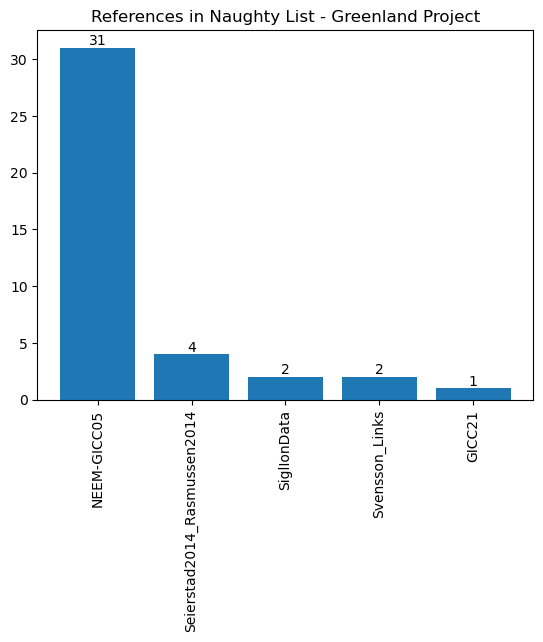

In [237]:
#reference bar plot

refs = []
for idx in appended_naughty:
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        refs.append(r)

counts = Counter(refs) #this counts the number of occurrences of each reference in the refs list

sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"References in Naughty List - {project} Project")
plt.show()

36


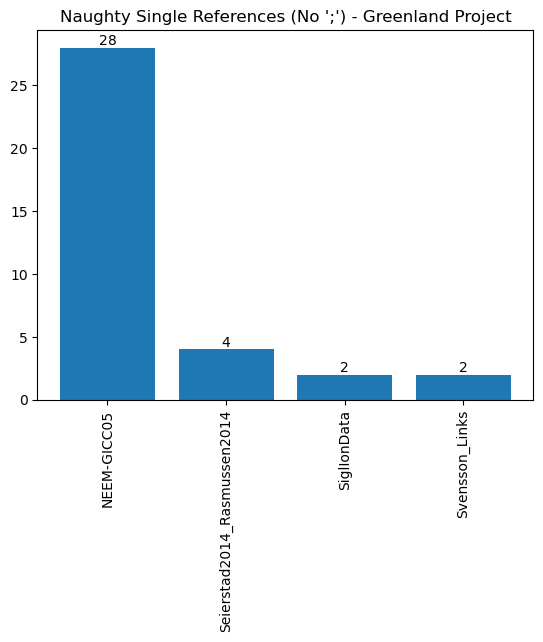

In [238]:
# reference bar plot (only single references — no ';')

full_refs_grab = []
for idx in appended_naughty:
    ref = get_reference(idx)
    full_refs_grab.append(ref)

single_refs = [r for r in full_refs_grab if ";" not in r]

print(len(single_refs))
counts_single = Counter(single_refs)

sorted_items = sorted(counts_single.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"Naughty Single References (No ';') - {project} Project")
plt.show()

2


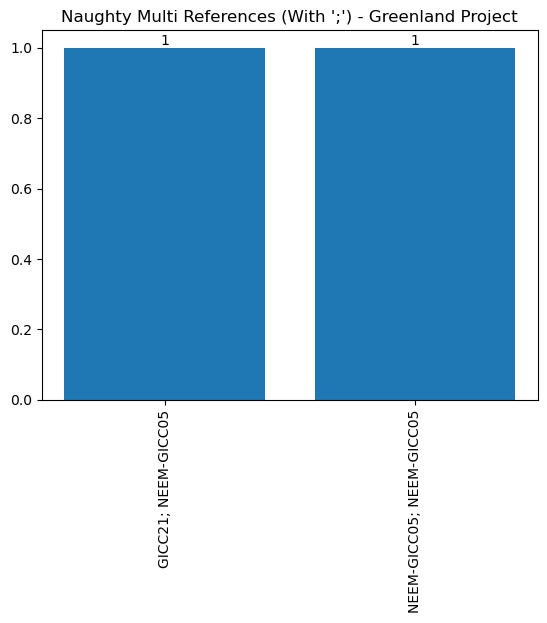

In [239]:
# reference bar plot (only multi references — ';')

full_refs_grab = []
for idx in appended_naughty:
    ref = get_reference(idx)
    full_refs_grab.append(ref)

single_refs = [r for r in full_refs_grab if ";" in r]

print(len(single_refs))
counts_single = Counter(single_refs)

sorted_items = sorted(counts_single.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"Naughty Multi References (With ';') - {project} Project")
plt.show()

In [240]:
# depths ratio bar plot

if project == 'Antarctic':
    depths = data['max_depths']
    depth_ratio = []
    order = ['EDC', 'WDC', 'EDML', 'DF', 'TALDICE']
    for idx in appended_naughty:
        ref = get_reference(idx)
        cores_row = big_table.loc[idx].dropna()
        core1 = cores_row.index[0].split("-")[0]
        core2 = cores_row.index[0].split("-")[1].split("_")[0]
        core1_depth = get_depth(core1, idx)
        core2_depth = get_depth(core2, idx)
        if core1 in order and core2 in order:
            core1_order = order.index(core1)
            core2_order = order.index(core2)
            core1_max = depths[core1_order]
            core2_max = depths[core2_order]
            
        ratio1 = core1_depth/core1_max
        ratio2 = core2_depth/core2_max
        for r in (ratio1, ratio2):
            depth_ratio.append(r)


    from matplotlib.ticker import PercentFormatter


    plt.figure()
    bars = plt.hist(depth_ratio, bins=40, weights=100*np.ones(len(depth_ratio)) / len(depth_ratio))

    plt.xticks(rotation=0)
    plt.xlabel("Depth of Tiepoint / Max Depth of Core")
    plt.ylabel("Frequency (%)")
    plt.title(f"Antarctic Naughty Tiepoint Depth Ratios - {project} Project")
    plt.show()
else:
    print("Depth ratio plot only available for Antarctic project, since it requires max depth data for each core.")

Depth ratio plot only available for Antarctic project, since it requires max depth data for each core.


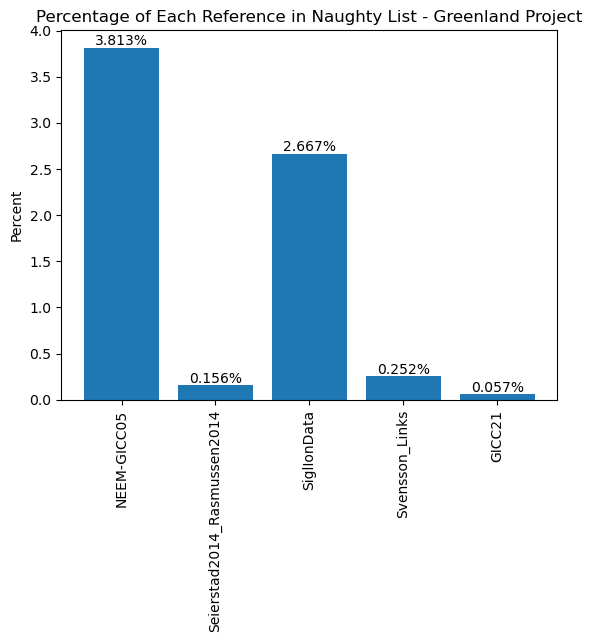

In [241]:
all_refs = []
for idx, row in big_table.iterrows():
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        all_refs.append(r)

all_counts = Counter(all_refs)
all_dict = dict(all_counts)

naughty_refs = []
for idx in appended_naughty:
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        naughty_refs.append(r)

naughty_counts = Counter(naughty_refs)
naughty_dict = dict(naughty_counts)

names = []
percentages = []
for c, v in naughty_dict.items():
    names.append(c)
    percentages.append(100*v/all_dict[f'{c}'])

bars = plt.bar(names, percentages)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.ylabel("Percent")
plt.title(f"Percentage of Each Reference in Naughty List - {project} Project")
plt.show()
    